# Penjelasan Kode — Percobaan 4: Klasifikasi Bunga (Mawar, Lili, Anggrek)

## Gambaran Besar

Percobaan 4 ini beda dari Percobaan 1-3 karena nggak cuma mengandalkan fitur **tekstur** (GLCM), tapi juga nambahin fitur **warna** (Histogram HSV). Alasannya masuk akal: mawar, lili, dan anggrek itu paling gampang dibedain dari warnanya, bukan dari teksturnya. Selain itu, proses grayscale-nya pakai **CLAHE** (versi pintar dari equalizeHist) biar kontras lebih merata.

Alur besarnya: **load gambar → preprocessing (2 jalur: gray+CLAHE dan warna) → ekstrak fitur GLCM → ekstrak fitur HSV → gabung jadi tabel → seleksi fitur korelasi → split & standardisasi → training 3 model (RF, SVM, KNN) → evaluasi & confusion matrix → simpan hasil**.

Berikut penjelasan tiap cell secara berurutan.

In [2]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Cell 1 (Code) — Import Library

```python
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns
```

**Penjelasan:** Semua library yang dipakai sepanjang notebook di-import di awal.
- `cv2 (OpenCV)` → baca gambar, resize, ubah warna, CLAHE, histogram warna.
- `numpy` → operasi array/matriks.
- `pandas` → bikin tabel fitur (DataFrame) dan simpan ke CSV.
- `skimage.feature (graycomatrix, graycoprops)` → hitung matriks GLCM dan properti teksturnya.
- `scipy.stats.entropy` → hitung entropy dari matriks GLCM.
- `sklearn` → model klasifikasi (RandomForest, SVM, KNN), split data, dan metrik evaluasi (accuracy, precision, recall, f1, confusion matrix).
- `matplotlib` & `seaborn` → visualisasi (gambar, heatmap, confusion matrix).

## 1. Load Dataset

In [3]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 300
Kelas: ['anggrek', 'lili', 'matahari']


## Cell 3 (Code) — Load Dataset dari Folder

```python
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")
```

**Penjelasan:** Folder `dataset` diasumsikan punya sub-folder per kelas, misalnya `dataset/mawar/`, `dataset/lili/`, `dataset/anggrek/`. Kode ini:
1. Looping tiap sub-folder (= nama kelas/label bunga).
2. Looping tiap file gambar di dalamnya, baca pakai `cv.imread()` (hasilnya array BGR).
3. Kalau gambar gagal dibaca (`img is None`, misalnya file korup), dilewati (`continue`).
4. Gambar asli (`img`), label kelasnya (`sub_folder`), dan nama file barunya dimasukkan ke list `data`, `labels`, `file_name`.

Di akhir, dicetak total data dan daftar kelas yang berhasil ke-load. Catatan: `IMG_SIZE` didefinisikan tapi nggak dipakai di sini — resize sebenarnya baru terjadi di tahap preprocessing (Cell 5-6)

## 2. Preprocessing

Karena sekarang kita butuh **dua versi** citra per gambar:
- versi **grayscale + CLAHE** → buat fitur tekstur (GLCM)
- versi **warna (resize doang)** → buat fitur warna (Histogram HSV)

In [4]:
TARGET_SIZE = (128, 128)

def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)

    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    return gray.astype(np.uint8)

def resize_color(image, target_size=TARGET_SIZE):
    # Tetap BGR (warna asli), khusus dipakai buat ekstraksi fitur warna HSV
    resized = cv.resize(image, target_size)
    return resized

def apply_clahe(gray_img, clip_limit=2.0, tile_grid_size=(8, 8)):
    # CLAHE = Contrast Limited Adaptive Histogram Equalization.
    # Beda sama equalizeHist() biasa (Percobaan 2) yang ngitung histogram dari SELURUH citra,
    # CLAHE membagi citra jadi tile-tile kecil (default 8x8) terus equalize tiap tile-nya
    # secara lokal -> kontras tekstur jadi lebih nendang tapi tetap stabil (clip_limit
    # mencegah noise ikut ter-amplifikasi).
    clahe = cv.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(gray_img)

## Cell 5 (Code) — Fungsi Resize & CLAHE

```python
TARGET_SIZE = (128, 128)

def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)

    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    return gray.astype(np.uint8)

def resize_color(image, target_size=TARGET_SIZE):
    # Tetap BGR (warna asli), khusus dipakai buat ekstraksi fitur warna HSV
    resized = cv.resize(image, target_size)
    return resized

def apply_clahe(gray_img, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(gray_img)
```

**Penjelasan tiap fungsi:**
- `resize_grayscale()` → resize gambar ke 128×128, lalu kalau gambarnya masih punya 3 channel (BGR), diubah jadi grayscale (1 channel). Hasilnya dipastikan bertipe `uint8` (0-255).
- `resize_color()` → cuma resize ke 128×128, tapi channel warnanya (BGR) tetap dipertahankan. Ini disiapkan khusus buat nanti diekstrak fitur warnanya.
- `apply_clahe()` → menerapkan **CLAHE**. Bedanya dengan `equalizeHist()` biasa (dipakai di Percobaan 2): equalizeHist menghitung histogram dari **seluruh gambar sekaligus**, sedangkan CLAHE membagi gambar jadi tile-tile kecil (default 8×8), lalu meratakan kontras di tiap tile secara lokal. Parameter `clip_limit=2.0` berfungsi membatasi seberapa jauh kontras boleh diperkuat di satu tile, supaya noise nggak ikut "dibesar-besarkan".

In [5]:
def prepro_gray(image):
    # Resize + Grayscale + CLAHE -> dipakai buat fitur tekstur (GLCM)
    img = resize_grayscale(image)
    img = apply_clahe(img)
    return img

def prepro_color(image):
    # Resize aja, tetap warna -> dipakai buat fitur warna (Histogram HSV)
    img = resize_color(image)
    return img

## Cell 6 (Code) — Fungsi Pipeline Preprocessing

```python
def prepro_gray(image):
    # Resize + Grayscale + CLAHE -> dipakai buat fitur tekstur (GLCM)
    img = resize_grayscale(image)
    img = apply_clahe(img)
    return img

def prepro_color(image):
    # Resize aja, tetap warna -> dipakai buat fitur warna (Histogram HSV)
    img = resize_color(image)
    return img
```

**Penjelasan:** Dua fungsi pembungkus (wrapper) yang menggabungkan langkah-langkah dari Cell 5 jadi satu alur:
- `prepro_gray()` → resize → grayscale → CLAHE. Outputnya nanti dipakai buat hitung GLCM.
- `prepro_color()` → cuma resize, warna tetap utuh. Outputnya nanti dipakai buat hitung histogram HSV.

## Cell 8 (Code) — Eksekusi Preprocessing + Tampilkan Grid Gambar

```python
def percobaan4(img):
    hasil_gray  = prepro_gray(img)
    hasil_color = prepro_color(img)
    return hasil_gray, hasil_color

hasil_prepro = [percobaan4(img) for img in data]
dataPreprocessedGray  = [h[0] for h in hasil_prepro]
dataPreprocessedColor = [h[1] for h in hasil_prepro]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(7, 10, figsize=(15, 10))
    fig.suptitle(f'{label} (grayscale + CLAHE)', fontsize=16)

    for k in range(min(70, len(idxs))):
        row = k // 10
        col = k % 10
        ax = axs[row][col]
        ax.imshow(dataPreprocessedGray[idxs[k]], cmap='gray')
        ax.axis('off')

    for k in range(len(idxs), 70):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()
```

**Penjelasan:**
1. Fungsi `percobaan4()` menjalankan kedua jalur preprocessing (gray dan color) sekaligus untuk satu gambar.
2. List comprehension `[percobaan4(img) for img in data]` menjalankan fungsi itu untuk **semua** gambar di `data`, hasilnya berupa pasangan `(gray, color)` per gambar.
3. Hasilnya dipisah jadi dua list terpisah: `dataPreprocessedGray` (buat GLCM nanti) dan `dataPreprocessedColor` (buat HSV nanti).
4. Bagian setelahnya murni **visualisasi**: untuk tiap kelas bunga, dibuat grid 7×10 (maksimal 70 gambar) berisi citra grayscale+CLAHE-nya, supaya bisa dicek visual apakah hasil CLAHE-nya masuk akal (kontras lebih jelas, dsb). Sel grid yang nggak terisi (kalau jumlah gambar kelas itu < 70) di-nonaktifkan axis-nya biar nggak tampil kotak kosong aneh.

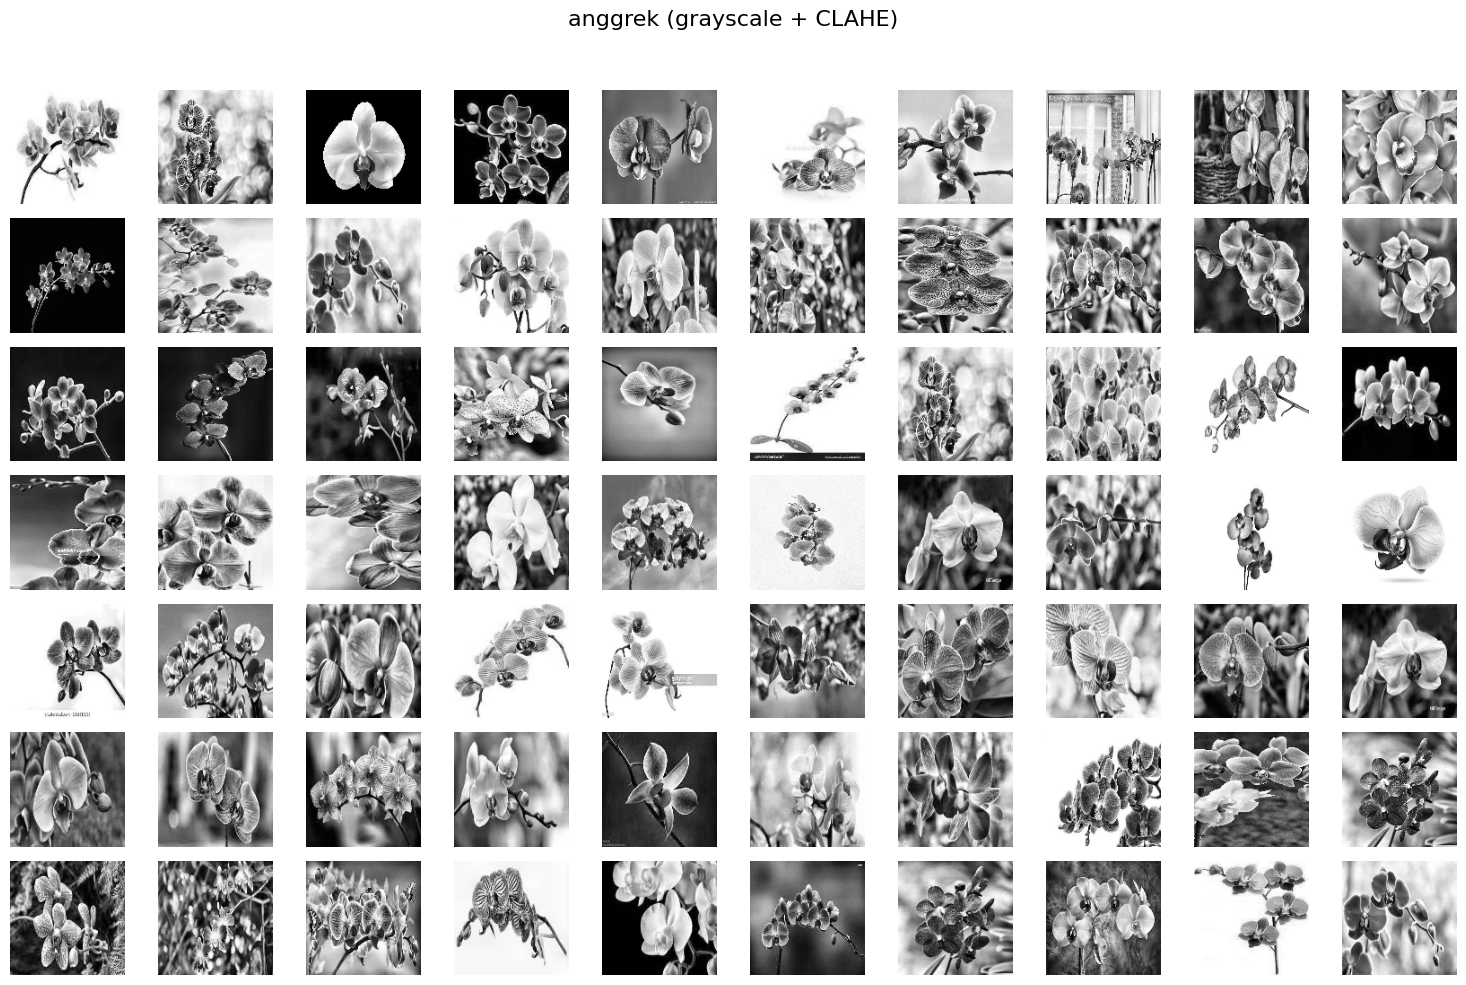

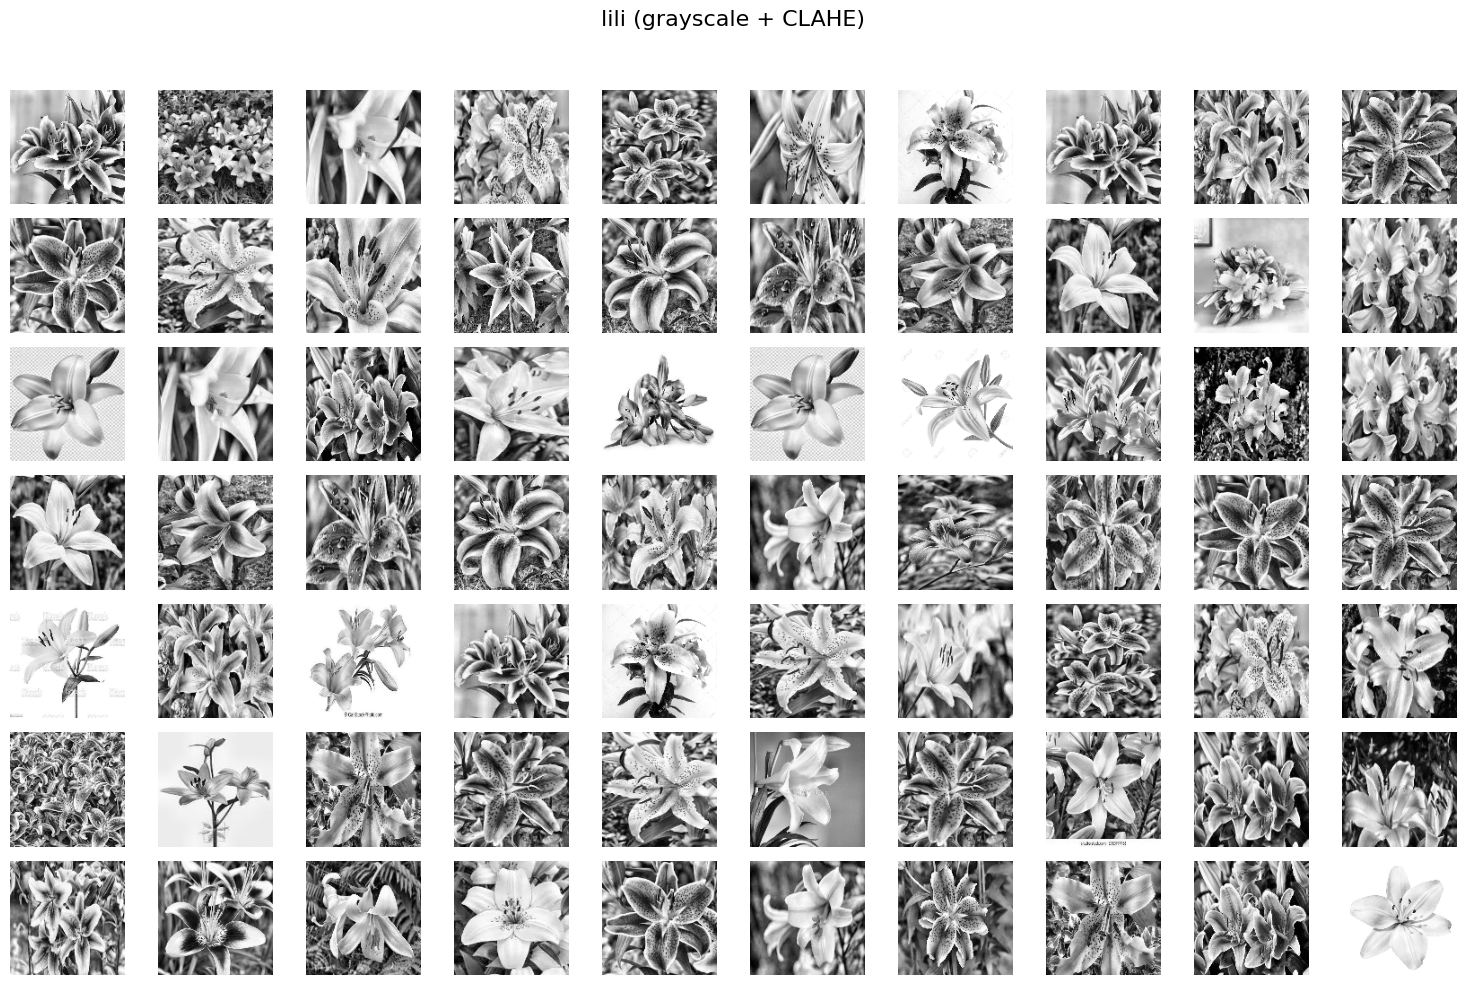

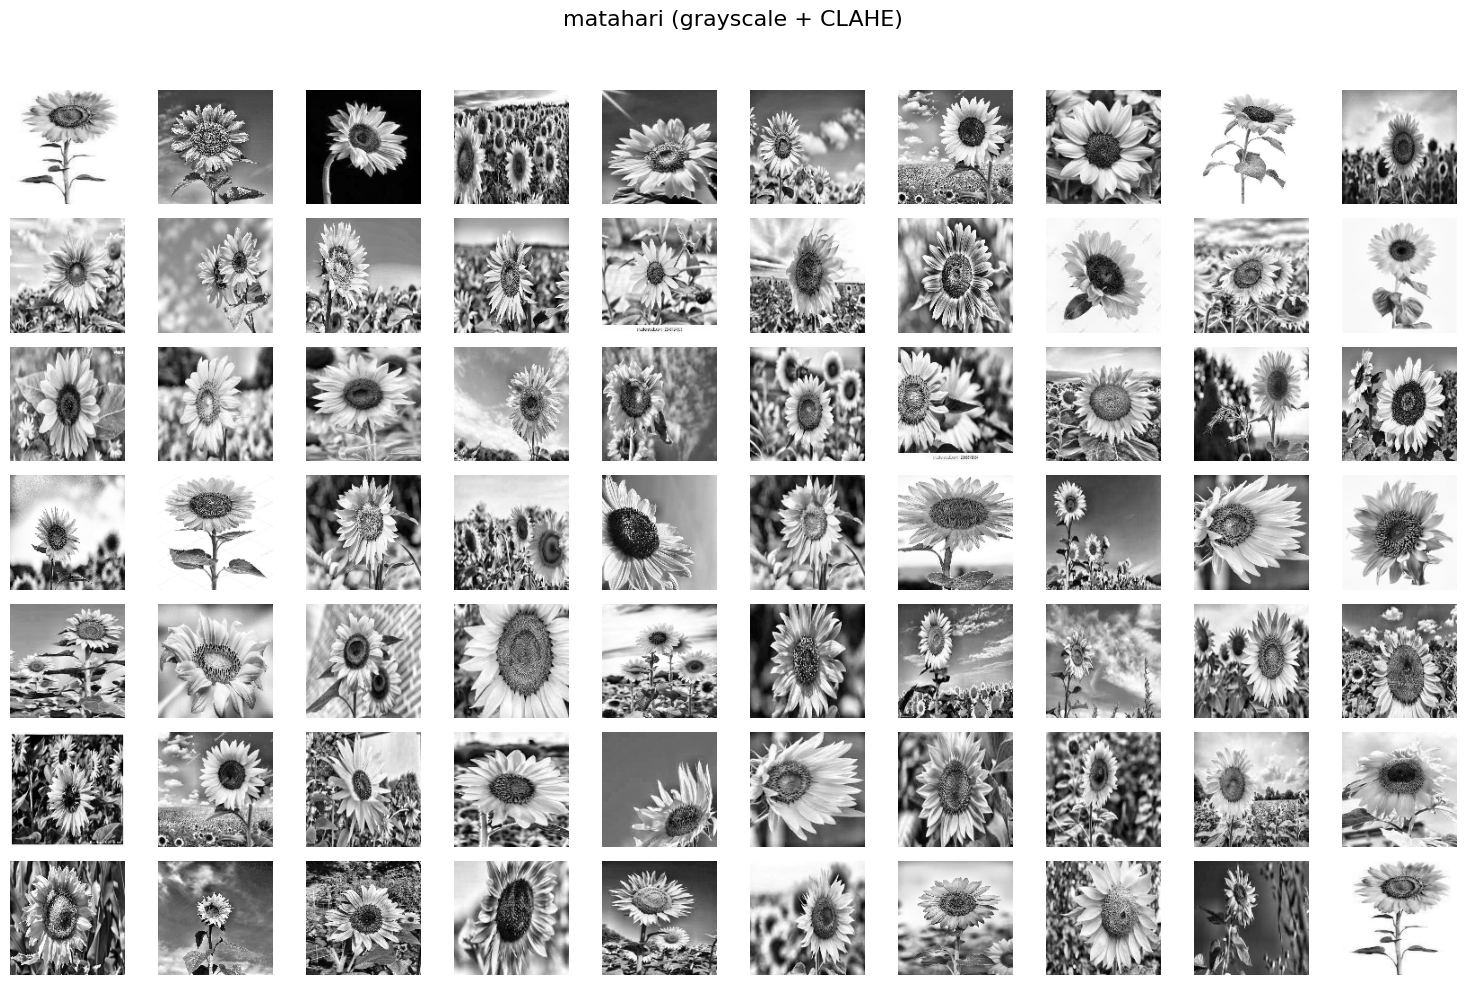

In [6]:
def percobaan4(img):
    hasil_gray  = prepro_gray(img)
    hasil_color = prepro_color(img)
    return hasil_gray, hasil_color

hasil_prepro = [percobaan4(img) for img in data]
dataPreprocessedGray  = [h[0] for h in hasil_prepro]
dataPreprocessedColor = [h[1] for h in hasil_prepro]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(7, 10, figsize=(15, 10))
    fig.suptitle(f'{label} (grayscale + CLAHE)', fontsize=16)

    for k in range(min(70, len(idxs))):

        row = k // 10
        col = k % 10

        ax = axs[row][col]

        ax.imshow(dataPreprocessedGray[idxs[k]], cmap='gray')
        ax.axis('off')

    for k in range(len(idxs), 70):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

## 4. Fungsi Ekstraksi Fitur Tekstur (GLCM) — sama seperti Percobaan 1-3

In [7]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

## Cell 10 (Code) — Fungsi Hitung Matriks GLCM

```python
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm
```

**Penjelasan:** GLCM (Gray Level Co-occurrence Matrix) adalah matriks yang menghitung seberapa sering pasangan nilai keabuan (gray level) muncul bersebelahan dalam arah dan jarak tertentu. Fungsi ini:
- Menerima `derajat` (0°, 45°, 90°, atau 135°) dan mengonversinya ke radian (`angles`) karena `graycomatrix` butuh input dalam radian.
- Memanggil `graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)`:
  - `[1]` → jarak antar piksel = 1.
  - `256` → jumlah level keabuan (0-255).
  - `symmetric=True` → matriks dibuat simetris (pasangan (i,j) dan (j,i) digabung).
  - `normed=True` → matriks dinormalisasi jadi nilai probabilitas (jumlah semua sel = 1).
- Mengembalikan matriks GLCM untuk satu arah tertentu.


In [8]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Cell 11 (Code) — Fungsi-fungsi Ekstraksi Properti GLCM

```python
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())
```

**Penjelasan:** Dari satu matriks GLCM, ada 7 properti statistik tekstur yang dihitung:
- **Correlation** → seberapa linier hubungan antar piksel tetangga.
- **Dissimilarity** → seberapa "beda" nilai piksel tetangga (mirip contrast tapi linier, bukan kuadrat).
- **Homogeneity** → seberapa seragam/halus tekstur (nilai tinggi = tekstur halus).
- **Contrast** → seberapa besar variasi intensitas lokal (nilai tinggi = tekstur kasar).
- **ASM (Angular Second Moment)** → ukuran keseragaman, nilai tinggi berarti tekstur sangat teratur.
- **Energy** → akar kuadrat dari ASM.
- **Entropy** → ukuran "ketidakteraturan"/keacakan tekstur, dihitung manual pakai `scipy.stats.entropy` dari matriks GLCM yang diratakan (`ravel()`), karena `graycoprops` bawaan skimage tidak menyediakan entropy.

Semua fungsi ini nanti dipanggil untuk tiap arah (0°, 45°, 90°, 135°), jadi totalnya **7 properti × 4 arah = 28 fitur tekstur** per gambar.

In [9]:
def color_histogram_hsv(image_bgr, bins=8):
    hsv = cv.cvtColor(image_bgr, cv.COLOR_BGR2HSV)

    hist_h = cv.calcHist([hsv], [0], None, [bins], [0, 180])
    hist_s = cv.calcHist([hsv], [1], None, [bins], [0, 256])
    hist_v = cv.calcHist([hsv], [2], None, [bins], [0, 256])

    hist_h = cv.normalize(hist_h, hist_h).flatten()
    hist_s = cv.normalize(hist_s, hist_s).flatten()
    hist_v = cv.normalize(hist_v, hist_v).flatten()

    return hist_h, hist_s, hist_v

## Cell 13 (Code) — Fungsi Ekstraksi Histogram HSV

```python
def color_histogram_hsv(image_bgr, bins=8):
    hsv = cv.cvtColor(image_bgr, cv.COLOR_BGR2HSV)

    hist_h = cv.calcHist([hsv], [0], None, [bins], [0, 180])
    hist_s = cv.calcHist([hsv], [1], None, [bins], [0, 256])
    hist_v = cv.calcHist([hsv], [2], None, [bins], [0, 256])

    hist_h = cv.normalize(hist_h, hist_h).flatten()
    hist_s = cv.normalize(hist_s, hist_s).flatten()
    hist_v = cv.normalize(hist_v, hist_v).flatten()

    return hist_h, hist_s, hist_v
```

**Penjelasan:**
1. Gambar BGR diubah ke ruang warna **HSV** (Hue, Saturation, Value) karena HSV memisahkan informasi warna (Hue) dari kecerahan (Value), lebih cocok buat membedakan warna bunga ketimbang RGB/BGR.
2. `cv.calcHist()` dipanggil 3 kali, satu per channel:
   - Channel 0 (Hue) → rentang nilai OpenCV 0-180 (bukan 0-360 seperti standar, karena disimpan dalam 8-bit).
   - Channel 1 (Saturation) → rentang 0-256.
   - Channel 2 (Value) → rentang 0-256.
   - Tiap histogram dibagi jadi `bins=8` kelompok nilai.
3. `cv.normalize()` menormalisasi tiap histogram supaya skalanya konsisten (nggak bias karena ukuran gambar beda-beda) — ini penting karena nanti histogram-histogram ini jadi fitur numerik buat model.
4. `flatten()` mengubah hasilnya jadi array 1 dimensi.

Hasil akhirnya: 8 fitur Hue + 8 fitur Saturation + 8 fitur Value = **24 fitur warna** per gambar.

In [10]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessedGray)):
    D0   = glcm(dataPreprocessedGray[i], 0)
    D45  = glcm(dataPreprocessedGray[i], 45)
    D90  = glcm(dataPreprocessedGray[i], 90)
    D135 = glcm(dataPreprocessedGray[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessedGray)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur tekstur (GLCM) selesai untuk {len(dataPreprocessedGray)} citra.")

Ekstraksi fitur tekstur (GLCM) selesai untuk 300 citra.


## Cell 15 (Code) — Eksekusi Ekstraksi GLCM untuk Semua Gambar

```python
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessedGray)):
    D0   = glcm(dataPreprocessedGray[i], 0)
    D45  = glcm(dataPreprocessedGray[i], 45)
    D90  = glcm(dataPreprocessedGray[i], 90)
    D135 = glcm(dataPreprocessedGray[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)


for i in range(len(dataPreprocessedGray)):
    Kontras0.append(contrast(Derajat0[i]))
    # ... dst untuk semua properti dan semua derajat

print(f"Ekstraksi fitur tekstur (GLCM) selesai untuk {len(dataPreprocessedGray)} citra.")
```

**Penjelasan:** Cell ini menjalankan dua tahap berurutan:
1. **Hitung matriks GLCM** untuk tiap gambar di 4 arah (0°, 45°, 90°, 135°) menggunakan fungsi `glcm()` dari Cell 10. Hasilnya disimpan di 4 list (`Derajat0`, `Derajat45`, `Derajat90`, `Derajat135`).
2. **Hitung 7 properti** (contrast, dissimilarity, homogeneity, entropy, ASM, energy, correlation) dari tiap matriks GLCM tadi, menggunakan fungsi-fungsi dari Cell 11. Karena ada 4 arah, masing-masing properti punya 4 versi (misal `Kontras0`, `Kontras45`, `Kontras90`, `Kontras135`).

Totalnya: 4 arah × 7 properti = 28 fitur tekstur per gambar, semuanya dikumpulkan dalam list-list terpisah.

### 3.4 Ekstraksi Fitur Tekstur (GLCM) — sama seperti Percobaan 1-3

GLCM (*Gray Level Co-occurrence Matrix*) itu intinya: **ngitung seberapa sering dua piksel bertetanggaan punya kombinasi tingkat keabuan tertentu**. Kalau teksturnya halus, piksel tetangga cenderung punya nilai mirip (matriksnya "rapi", numpuk di diagonal). Kalau teksturnya kasar/acak, nilainya nyebar.

Dari matriks GLCM itu, diambil 7 properti:

| Properti | Artinya secara intuitif |
|---|---|
| **Contrast** | Seberapa besar perbedaan intensitas antar piksel tetangga — makin tinggi, teksturnya makin "kasar"/tajam |
| **Homogeneity** | Seberapa seragam/mulus teksturnya — kebalikan dari contrast |
| **Dissimilarity** | Mirip contrast, tapi diukur linear (bukan kuadrat) |
| **Entropy** | Seberapa "acak"/kompleks pola teksturnya |
| **ASM** (Angular Second Moment) | Seberapa seragam pola berulang di gambar |
| **Energy** | Akar dari ASM — versi "ternormalisasi"-nya |
| **Correlation** | Seberapa linear hubungan antar piksel tetangga |

Dan ini dihitung di **4 arah berbeda**: 0°, 45°, 90°, 135°. Kenapa 4 arah? Karena tekstur bisa punya orientasi tertentu — misal urat daun yang dominan horizontal vs kelopak yang seratnya menyebar diagonal. Kalau cuma dicek satu arah, bisa aja kelewat pola yang sebenarnya kuat di arah lain.

Total: **7 properti × 4 arah = 28 fitur tekstur**.

## 7. Jalankan Ekstraksi Fitur Warna (Histogram HSV)

In [11]:
Hue_feats = []
Sat_feats = []
Val_feats = []

for i in range(len(dataPreprocessedColor)):
    h, s, v = color_histogram_hsv(dataPreprocessedColor[i], bins=8)
    Hue_feats.append(h)
    Sat_feats.append(s)
    Val_feats.append(v)

Hue_feats = np.array(Hue_feats)
Sat_feats = np.array(Sat_feats)
Val_feats = np.array(Val_feats)

total_fitur_warna = Hue_feats.shape[1] + Sat_feats.shape[1] + Val_feats.shape[1]
print(f"Ekstraksi fitur warna (HSV histogram) selesai untuk {len(dataPreprocessedColor)} citra.")
print(f"Jumlah fitur warna per citra: {total_fitur_warna} "
      f"(Hue {Hue_feats.shape[1]} + Sat {Sat_feats.shape[1]} + Val {Val_feats.shape[1]})")

Ekstraksi fitur warna (HSV histogram) selesai untuk 300 citra.
Jumlah fitur warna per citra: 24 (Hue 8 + Sat 8 + Val 8)


## Cell 17 (Code) — Eksekusi Ekstraksi Histogram HSV untuk Semua Gambar

```python
Hue_feats = []
Sat_feats = []
Val_feats = []

for i in range(len(dataPreprocessedColor)):
    h, s, v = color_histogram_hsv(dataPreprocessedColor[i], bins=8)
    Hue_feats.append(h)
    Sat_feats.append(s)
    Val_feats.append(v)

Hue_feats = np.array(Hue_feats)
Sat_feats = np.array(Sat_feats)
Val_feats = np.array(Val_feats)

total_fitur_warna = Hue_feats.shape[1] + Sat_feats.shape[1] + Val_feats.shape[1]
print(f"Ekstraksi fitur warna (HSV histogram) selesai untuk {len(dataPreprocessedColor)} citra.")
print(f"Jumlah fitur warna per citra: {total_fitur_warna} "
      f"(Hue {Hue_feats.shape[1]} + Sat {Sat_feats.shape[1]} + Val {Val_feats.shape[1]})")
```

**Penjelasan:** Loop ini memanggil fungsi `color_histogram_hsv()` (Cell 13) untuk tiap gambar versi warna (`dataPreprocessedColor`), menghasilkan 3 histogram (Hue, Saturation, Value) per gambar. Hasilnya dikumpulkan dalam list lalu diubah jadi `numpy array` 2 dimensi (baris = gambar, kolom = bin histogram). Di akhir, dicetak ringkasan jumlah total fitur warna (8+8+8 = 24).

### 3.5 Ekstraksi Fitur Warna (Histogram HSV) — BARU di Percobaan 4

```python
hsv = cv.cvtColor(image_bgr, cv.COLOR_BGR2HSV)
hist_h = cv.calcHist([hsv], [0], None, [bins], [0, 180])
```

Gambar warna BGR dikonversi dulu ke ruang warna **HSV**, karena HSV lebih "manusiawi" buat ngerepresentasiin warna dibanding BGR:

| Channel | Analoginya |
|---|---|
| **Hue (H)** | "Jenis" warnanya — merah, ungu, kuning, dst. Ini paling penting buat bedain mawar (cenderung merah/pink), anggrek (cenderung ungu/putih), lili (lebih variatif) |
| **Saturation (S)** | Kepekatan warnanya — warna pucat vs warna pekat/jenuh |
| **Value (V)** | Terang-gelapnya warna |

Tiap channel itu dipecah jadi **8 bin** histogram — bayangin kayak ngebagi roda warna jadi 8 potongan, terus dihitung berapa piksel yang jatuh di tiap potongan. Hasil hitungannya dinormalisasi (skala 0-1) biar nggak bias gara-gara ukuran gambar.

Total: **3 channel × 8 bin = 24 fitur warna**.


## 8. Gabungkan Fitur Tekstur + Warna jadi Satu Tabel

In [12]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

# Tambahin kolom fitur warna HSV (Hue0..7, Sat0..7, Val0..7)
for b in range(Hue_feats.shape[1]):
    dataTable[f'Hue{b}'] = Hue_feats[:, b]
for b in range(Sat_feats.shape[1]):
    dataTable[f'Sat{b}'] = Sat_feats[:, b]
for b in range(Val_feats.shape[1]):
    dataTable[f'Val{b}'] = Val_feats[:, b]

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_pros4.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_pros4.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,Sat6,Sat7,Val0,Val1,Val2,Val3,Val4,Val5,Val6,Val7
0,anggrek_1.jpg,anggrek,848.852239,1229.452663,570.595226,978.020212,0.486248,0.466012,0.498289,0.464005,...,0.015896,0.025560,0.004993,0.014182,0.007887,0.005065,0.011360,0.032345,0.117367,0.992339
1,anggrek_2.jpg,anggrek,1532.110544,1781.939550,1198.967827,1617.381983,0.123703,0.099203,0.160092,0.105524,...,0.102928,0.159861,0.000114,0.026609,0.064818,0.107802,0.172506,0.201730,0.442806,0.846722
2,anggrek_3.jpg,anggrek,771.220226,998.231260,568.339444,946.539029,0.673530,0.651412,0.677011,0.655732,...,0.006010,0.035492,0.937037,0.000552,0.000827,0.015076,0.022155,0.041920,0.236626,0.251979
3,anggrek_4.jpg,anggrek,1498.091966,2039.802654,1365.777621,2357.944200,0.389689,0.360757,0.389721,0.358977,...,0.148759,0.677150,0.926766,0.063836,0.149096,0.225873,0.219348,0.107227,0.053614,0.035996
4,anggrek_5.jpg,anggrek,766.632074,897.030504,413.547490,837.938062,0.315196,0.287864,0.428865,0.284227,...,0.079027,0.188346,0.004671,0.013330,0.569200,0.770061,0.111197,0.167821,0.203937,0.026432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,matahari_96.jpg,matahari,185.753199,285.181102,211.249016,356.712505,0.582465,0.564308,0.609825,0.564363,...,0.077454,0.234238,0.003613,0.005088,0.028684,0.048150,0.070123,0.039375,0.018065,0.995000
296,matahari_97.jpg,matahari,1022.975517,1286.612313,555.319636,1249.299833,0.079682,0.065754,0.106231,0.067220,...,0.135084,0.464515,0.033330,0.122211,0.579130,0.569989,0.356085,0.211091,0.044581,0.387727
297,matahari_98.jpg,matahari,843.784510,1040.883874,401.297060,1030.821564,0.086566,0.067246,0.115564,0.069467,...,0.177508,0.776776,0.011556,0.086529,0.199130,0.641219,0.497896,0.155865,0.279318,0.437438
298,matahari_99.jpg,matahari,548.173474,764.540145,343.923536,659.889144,0.116160,0.092738,0.160204,0.095301,...,0.129074,0.958270,0.032795,0.263135,0.075532,0.078501,0.192897,0.226854,0.459647,0.786047


## Cell 19 (Code) — Gabungkan Semua Fitur jadi DataFrame & Simpan CSV

```python
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, ... ,
    'Dissimilarity0': dissimilarity0, ... ,
    'Entropy0': entropy0, ... ,
    'ASM0': ASM0, ... ,
    'Energy0': energy0, ... ,
    'Correlation0': correlation0, ... ,
}

# Tambahin kolom fitur warna HSV (Hue0..7, Sat0..7, Val0..7)
for b in range(Hue_feats.shape[1]):
    dataTable[f'Hue{b}'] = Hue_feats[:, b]
for b in range(Sat_feats.shape[1]):
    dataTable[f'Sat{b}'] = Sat_feats[:, b]
for b in range(Val_feats.shape[1]):
    dataTable[f'Val{b}'] = Val_feats[:, b]

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_pros4.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_pros4.csv')
hasilEkstrak
```

**Penjelasan:**
1. Sebuah dictionary `dataTable` dibangun, berisi kolom `Filename`, `Label`, dan **28 kolom fitur tekstur GLCM** (7 properti × 4 derajat).
2. Lewat loop `for b in range(...)`, ditambahkan **24 kolom fitur warna HSV** (`Hue0`-`Hue7`, `Sat0`-`Sat7`, `Val0`-`Val7`), diambil per kolom (`Hue_feats[:, b]` artinya ambil bin ke-`b` dari semua gambar).
3. Dictionary itu diubah jadi `pandas DataFrame` (`df`), lalu disimpan ke file `hasil_ekstraksi_pros4.csv` — jadi total ada 2 (identitas) + 28 (tekstur) + 24 (warna) = **54 kolom**.
4. File CSV dibaca ulang ke variabel `hasilEkstrak` dan ditampilkan sebagai tabel — ini berguna supaya proses ekstraksi fitur nggak perlu diulang dari nol kalau notebook dijalankan ulang (cukup baca CSV-nya).

## Cell 21 (Code) — Seleksi Fitur Berdasarkan Korelasi + Heatmap

```python
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

jumlah_fitur_awal = hasilEkstrak.drop(columns=['Label','Filename']).shape[1]
print(f"Fitur sebelum seleksi : {jumlah_fitur_awal}")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(20,20))
sns.heatmap(x_new.corr(), annot=True, cmap='Reds', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 4', fontsize=14)
plt.show()
```

**Penjelasan:**
1. `corr_matrix` → matriks korelasi antar semua kolom fitur (kolom `Label` dan `Filename` dibuang dulu karena bukan angka/bukan fitur numerik).
2. `columns` → array boolean (awalnya semua `True`), menandai fitur mana yang "dipertahankan".
3. Loop bersarang (`for i`, `for j`) mengecek tiap pasangan fitur (i, j) di atas diagonal. Kalau korelasinya (nilai absolut) ≥ `threshold` (0.95), berarti dua fitur itu nyaris kembar — fitur ke-`j` ditandai `False` (dibuang), fitur ke-`i` dipertahankan.
4. `select` → daftar nama kolom fitur yang lolos seleksi (yang masih `True`).
5. `x_new` → tabel fitur final (sudah tanpa redundansi), `y` → label kelas bunga.
6. Dicetak jumlah fitur sebelum dan sesudah seleksi, plus daftar nama fitur yang terpilih.
7. Terakhir, digambar **heatmap korelasi** dari fitur-fitur yang sudah lolos seleksi, supaya bisa divisualisasikan secara visual bahwa fitur-fitur yang tersisa nggak lagi terlalu berkorelasi tinggi satu sama lain.

Fitur sebelum seleksi : 52
Fitur setelah seleksi : 34
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Dissimilarity0', 'Dissimilarity90', 'ASM0', 'Correlation0', 'Correlation45', 'Correlation90', 'Hue0', 'Hue1', 'Hue2', 'Hue3', 'Hue4', 'Hue5', 'Hue6', 'Hue7', 'Sat0', 'Sat1', 'Sat2', 'Sat3', 'Sat4', 'Sat5', 'Sat6', 'Sat7', 'Val0', 'Val1', 'Val2', 'Val3', 'Val4', 'Val5', 'Val6', 'Val7']


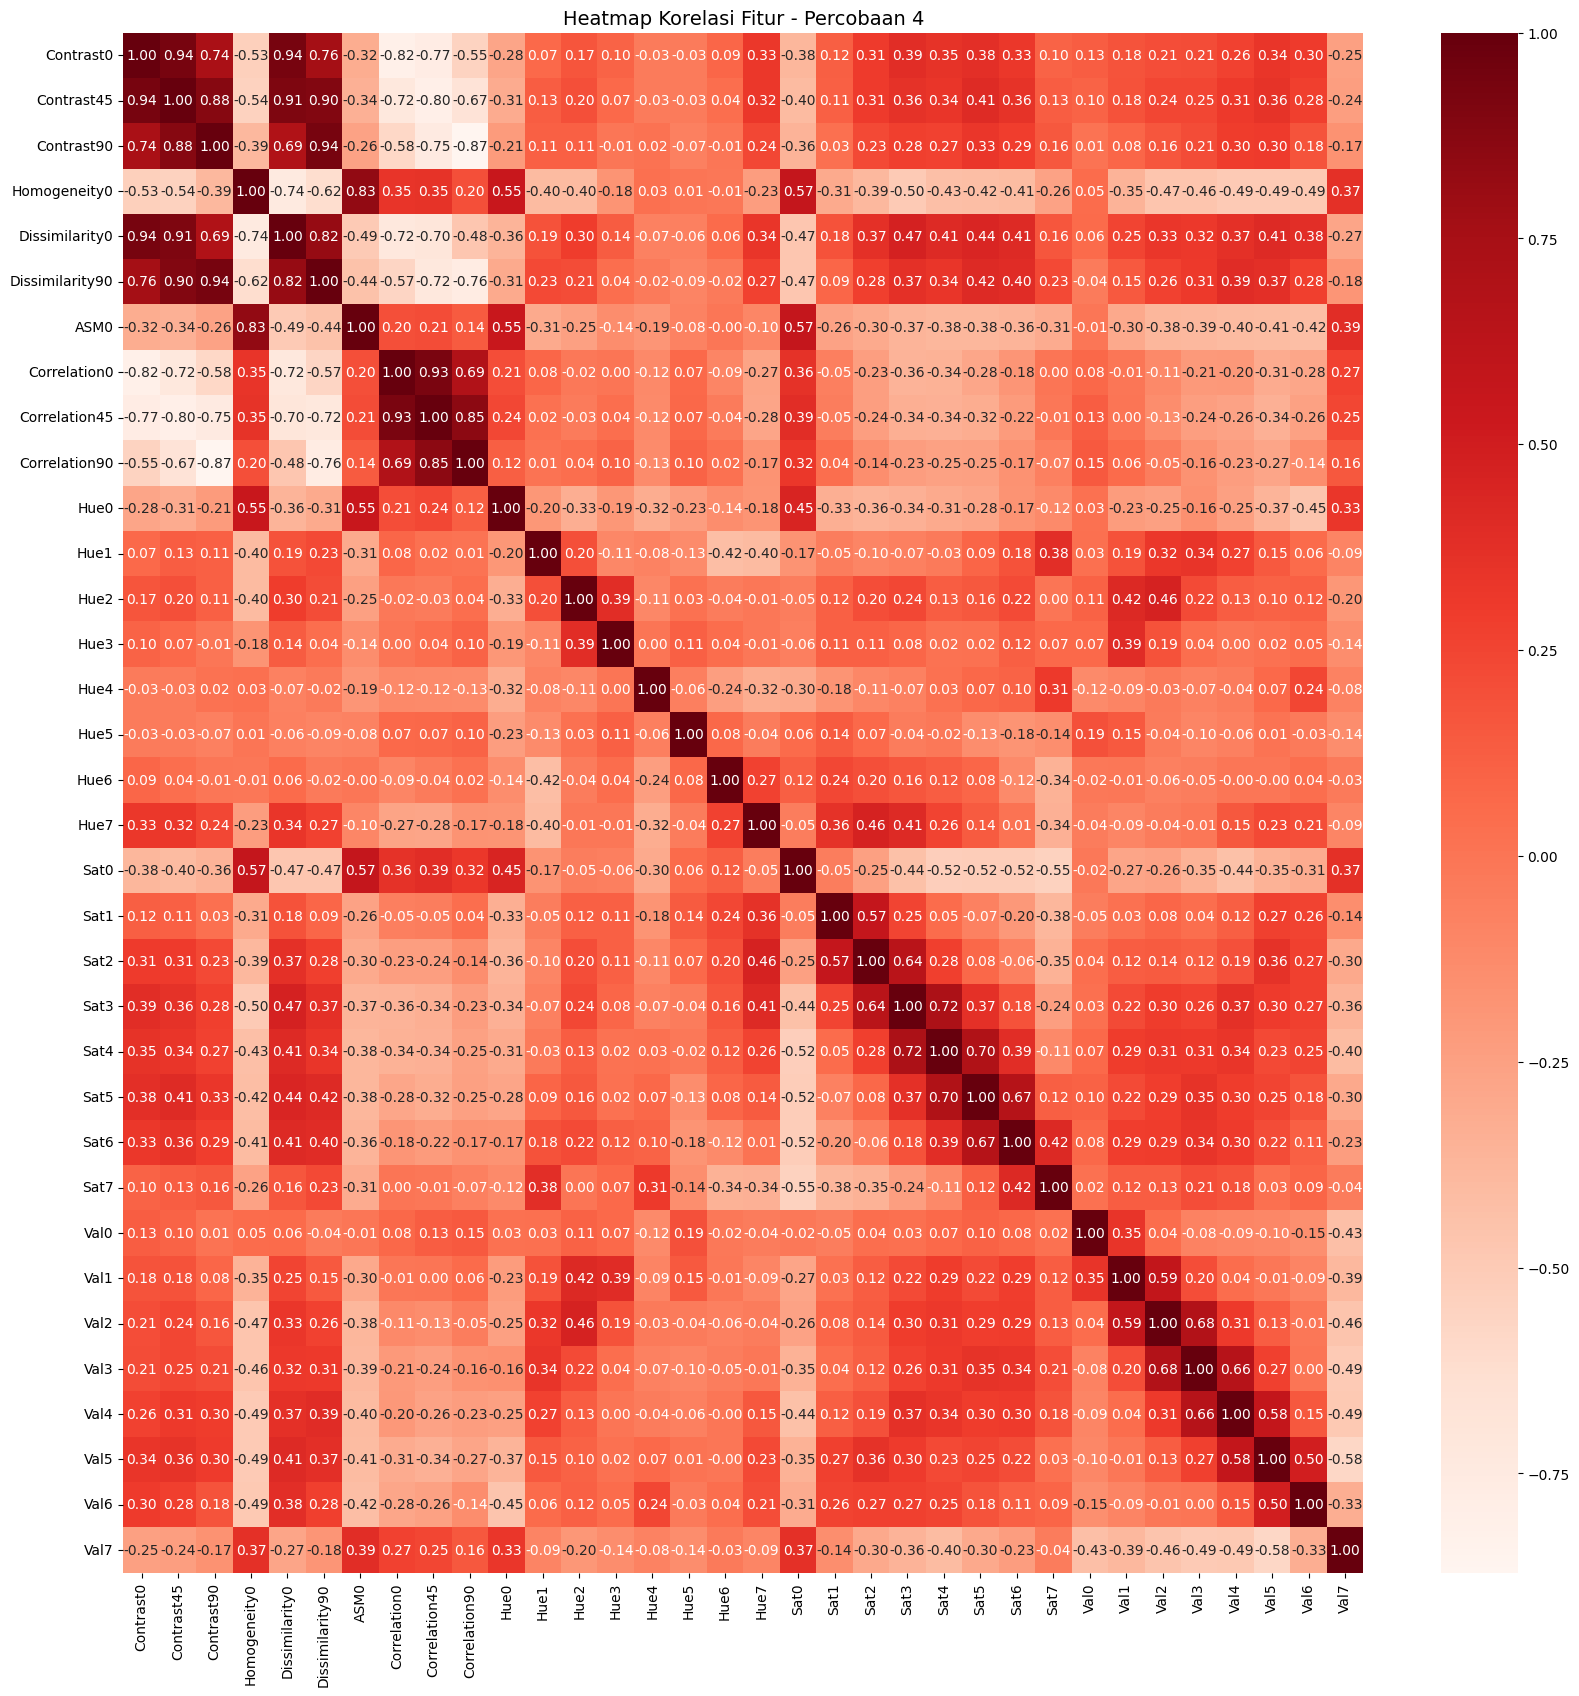

In [13]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

jumlah_fitur_awal = hasilEkstrak.drop(columns=['Label','Filename']).shape[1]
print(f"Fitur sebelum seleksi : {jumlah_fitur_awal}")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(20,20))
sns.heatmap(x_new.corr(), annot=True, cmap='Reds', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 4', fontsize=14)
plt.show()

## 10. Split Data & Standardisasi

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)

(240, 34)
(60, 34)


## Cell 23 (Code) — Split Data Train/Test

```python
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)
```

**Penjelasan:** Data fitur (`x_new`) dan label (`y`) dipecah jadi data latih (`X_train`, `y_train`, 80%) dan data uji (`X_test`, `y_test`, 20%). Parameter penting:
- `random_state=42` → supaya hasil split selalu sama tiap kali dijalankan ulang (reproducible).
- `stratify=y` → memastikan proporsi tiap kelas bunga (mawar/lili/anggrek) di data train dan test sebanding, nggak ada kelas yang kebetulan dominan di salah satu sisi.

Dicetak juga bentuk (`shape`) dari `X_train` dan `X_test` untuk memastikan jumlah barisnya sesuai harapan.


In [15]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

## Cell 24 (Code) — Standardisasi Fitur (Z-score)

```python
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train
```

**Penjelasan:** Ini adalah proses **standardisasi manual** (Z-score normalization): tiap fitur dikurangi rata-ratanya lalu dibagi standar deviasinya, sehingga semua fitur punya skala yang sebanding (rata-rata ≈ 0, standar deviasi ≈ 1). Ini penting terutama untuk SVM dan KNN yang sensitif terhadap skala fitur.

Catatan teknis penting: `mean_train` dan `std_train` dihitung **hanya dari `X_train`**, lalu dipakai untuk menstandardisasi baik `X_train` maupun `X_test`. Ini praktik yang benar — mencegah "kebocoran informasi" (data leakage) dari data uji ke proses training.

## 11. Definisikan Model Klasifikasi

In [16]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf  = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=4, min_samples_leaf=2, max_features='sqrt', random_state=42)
svm = SVC(kernel='rbf', random_state=42, C=5, gamma='scale', class_weight='balanced')
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')

## Cell 26 (Code) — Fungsi Evaluasi & Definisi 3 Model

```python
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf  = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=4, min_samples_leaf=2, max_features='sqrt', random_state=42)
svm = SVC(kernel='rbf', random_state=42, C=5, gamma='scale', class_weight='balanced')
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
```

**Penjelasan:**
- `generateClassificationReport()` → fungsi bantu yang mencetak `classification_report` (precision, recall, f1-score per kelas), `confusion_matrix`, dan `accuracy_score` sekaligus, supaya nggak perlu ditulis ulang tiap kali evaluasi model.
- **Random Forest (`rf`)** → kumpulan 200 pohon keputusan (`n_estimators=200`), kedalaman maksimal tiap pohon dibatasi 8 (`max_depth=8`) untuk mencegah overfitting, `max_features='sqrt'` artinya tiap split pohon hanya mempertimbangkan akar dari jumlah total fitur secara acak (teknik standar Random Forest).
- **SVM (`svm`)** → menggunakan kernel RBF (non-linear), `C=5` mengatur trade-off antara margin lebar vs kesalahan klasifikasi, `class_weight='balanced'` otomatis memberi bobot lebih ke kelas yang lebih sedikit datanya (kalau data tidak seimbang antar kelas).
- **KNN (`knn`)** → mempertimbangkan 7 tetangga terdekat (`n_neighbors=7`), `weights='distance'` artinya tetangga yang lebih dekat punya pengaruh suara (vote) lebih besar dibanding yang jauh.

Ketiga model ini baru **didefinisikan**, belum dilatih.

In [17]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     anggrek       0.99      1.00      0.99        80
        lili       1.00      0.99      0.99        80
    matahari       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

[[80  0  0]
 [ 1 79  0]
 [ 0  0 80]]
Accuracy: 0.9958333333333333

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.94      0.75      0.83        20
        lili       0.75      0.90      0.82        20
    matahari       0.95      0.95      0.95        20

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60

[[15  5  0]
 [ 1 18  1]
 [ 0  1 19]]
Accuracy: 0.8666666666666667


## Cell 27 (Code) — Training & Evaluasi Random Forest

```python
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)
```

**Penjelasan:** Model Random Forest dilatih (`fit`) memakai data training, lalu dievaluasi dua kali: sekali memprediksi data **training sendiri** (untuk melihat seberapa baik model "menghafal" datanya — kalau akurasi training jauh lebih tinggi dari testing, itu tanda overfitting), dan sekali memprediksi data **testing** (data yang belum pernah dilihat model, ini ukuran performa yang sebenarnya).

In [18]:
# Train SVM Classifier
svm.fit(X_train, y_train)

print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       0.99      1.00      0.99        80
        lili       1.00      0.99      0.99        80
    matahari       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

[[80  0  0]
 [ 1 79  0]
 [ 0  0 80]]
Accuracy: 0.9958333333333333

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.76      0.65      0.70        20
        lili       0.74      0.85      0.79        20
    matahari       0.90      0.90      0.90        20

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60

[[13  6  1]
 [ 2 17  1]
 [ 2  0 18]]
Accuracy: 0.8


## Cell 28 (Code) — Training & Evaluasi SVM

```python
svm.fit(X_train, y_train)

print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)
```

**Penjelasan:** Sama persis pola dengan Cell 27, tapi untuk model SVM. Dilatih, lalu dievaluasi di training set dan testing set.

In [19]:
# Train KNN Classifier
knn.fit(X_train, y_train)

print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       1.00      1.00      1.00        80
        lili       1.00      1.00      1.00        80
    matahari       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

[[80  0  0]
 [ 0 80  0]
 [ 0  0 80]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.92      0.60      0.73        20
        lili       0.68      0.85      0.76        20
    matahari       0.86      0.95      0.90        20

    accuracy                           0.80        60
   macro avg       0.82      0.80      0.80        60
weighted avg       0.82      0.80      0.80        60

[[12  7  1]
 [ 1 17  2]
 [ 0  1 19]]
Accuracy: 0.8


## Cell 29 (Code) — Training & Evaluasi KNN

```python
knn.fit(X_train, y_train)

print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)
```

**Penjelasan:** Sama lagi polanya, sekarang untuk model KNN. Setelah cell ini, ketiga model (`rf`, `svm`, `knn`) sudah terlatih dan siap dibandingkan.

### 3.10 Evaluasi & Confusion Matrix

| Metrik | Artinya |
|---|---|
| **Accuracy** | Persentase tebakan yang bener dari semua data |
| **Precision** | Dari yang ditebak "mawar", berapa persen yang beneran mawar |
| **Recall** | Dari semua yang beneran mawar, berapa persen yang berhasil ketebak |
| **F1-Score** | Rata-rata harmonis precision & recall |

**Confusion matrix** itu tabel yang nunjukin: dari tiap kelas asli (baris), model nebaknya jadi kelas apa aja (kolom). Berguna buat lihat kelas mana yang paling sering ketuker (misal lili sering ketebak anggrek).

## Cell 31 (Code) — Visualisasi Confusion Matrix untuk 3 Model

```python
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Reds)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan 4")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan 4")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan 4")
```

**Penjelasan:** Fungsi `plot_confusion_matrix()` menggambar confusion matrix (tabel prediksi benar vs salah per kelas) dalam bentuk heatmap berwarna merah, lengkap dengan judul. Fungsi ini dipanggil 3 kali, satu per model, semuanya dievaluasi memakai data **testing** (`X_test`, `y_test`) — supaya bisa langsung dibandingkan secara visual model mana yang paling sering salah mengklasifikasi kelas bunga tertentu (misalnya sering ketukar antara mawar dan anggrek).

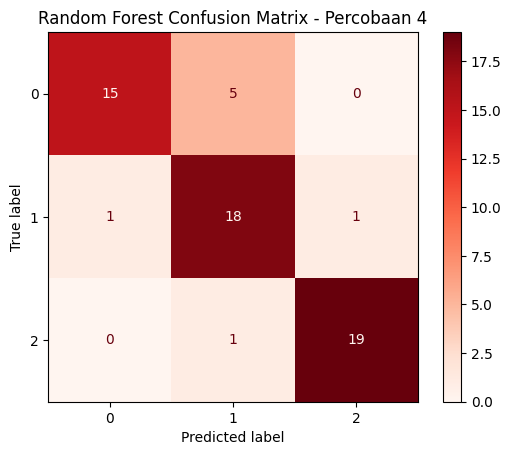

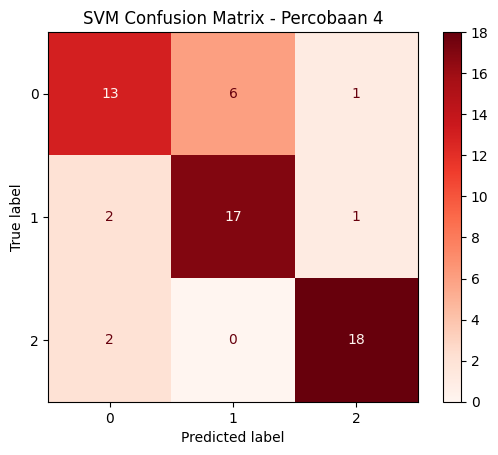

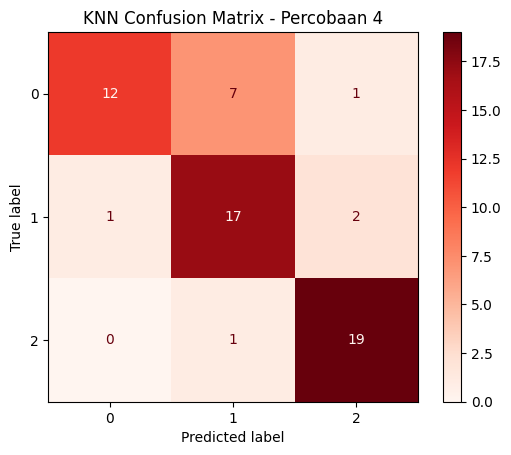

In [20]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Reds)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan 4")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan 4")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan 4")

## 13. Ringkasan & Simpan Hasil Perbandingan Model

In [21]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('hasil_klasifikasi_pros4.csv', index=False)
print("✅ File hasil_klasifikasi_pros4.csv berhasil disimpan.")
df_hasil

✅ File hasil_klasifikasi_pros4.csv berhasil disimpan.


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.995833,0.866667,0.879167,0.866667,0.867172
1,SVM,0.995833,0.800000,0.801279,0.800000,0.797800
2,KNN,1.000000,0.800000,0.822238,0.800000,0.795863


## Cell 33 (Code) — Rangkum Metrik & Simpan ke CSV

```python
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [...],
    'Precision': [...],
    'Recall': [...],
    'F1_Score': [...],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('hasil_klasifikasi_pros4.csv', index=False)
print("✅ File hasil_klasifikasi_pros4.csv berhasil disimpan.")
df_hasil
```

**Penjelasan:** Cell terakhir ini merangkum performa ketiga model dalam satu tabel perbandingan, berisi:
- **Accuracy_Train** & **Accuracy_Test** → akurasi di data latih vs data uji (selisih besar = indikasi overfitting).
- **Precision**, **Recall**, **F1_Score** → dihitung dengan `average='weighted'`, artinya skor tiap kelas dirata-rata dengan bobot sesuai jumlah datanya, cocok dipakai meski jumlah data per kelas tidak sama persis. `zero_division=0` mencegah error kalau ada kelas yang kebetulan tidak pernah diprediksi sama sekali.

Tabel hasil ini disimpan ke `hasil_klasifikasi_pros4.csv` supaya bisa dibandingkan langsung dengan hasil Percobaan 1-3 — inilah inti dari eksperimen ini: melihat apakah menambahkan fitur warna (HSV) ke fitur tekstur (GLCM) benar-benar meningkatkan akurasi klasifikasi tiga jenis bunga ini.

## Ringkasan Fitur yang Dipakai

| Sumber Fitur | Jumlah | Detail |
|---|---|---|
| GLCM (tekstur) | 28 | 7 properti (contrast, dissimilarity, homogeneity, entropy, ASM, energy, correlation) × 4 arah (0°, 45°, 90°, 135°) |
| Histogram HSV (warna) | 24 | 8 bin × 3 channel (Hue, Saturation, Value) |
| **Total sebelum seleksi** | **52** | Belum termasuk kolom Filename & Label |
| Setelah seleksi korelasi | bervariasi | Fitur dengan korelasi ≥ 0.95 terhadap fitur lain dibuang |
